# Global Layoffs Data Analysis (2020-2026)
This project analyzes global layoff trends across companies, industries, and countries.

Tools Used:
- Python
- Pandas
- Matplotlib

Goals:
- Analyze layoffs trends over time
- Identify industries and countries most affected
- Explore major layoff events
- Examine relationship between funding and layoffs

## 1.Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 2.Load Dataset

In [2]:
df=pd.read_csv("../1_data/1_raw/layoffs.csv")
df


,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Block,SF Bay Area,4000.0,2/26/2026,0.40,Finance,https://www.cnbc.com/2026/02/26/block-laying-o...,Post-IPO,150.0,United States,2/26/2026
1,eBay,SF Bay Area,800.0,2/26/2026,0.06,Retail,https://www.cnbc.com/2026/02/26/ebay-layoffs-8...,Post-IPO,1200.0,Israel,2/26/2026
2,C3.ai,SF Bay Area,280.0,2/25/2026,0.26,AI,https://www.morningstar.com/stocks/xnys/ai/ear...,Series F,228.0,United States,2/26/2026
3,WiseTech,"Sydney, Non-U.S.",2000.0,2/24/2026,0.30,Logistics,https://www.bloomberg.com/news/articles/2026-0...,Post-IPO,3000.0,Australia,2/25/2026
4,TrueCar,Los Angeles,100.0,2/24/2026,0.30,Transportation,https://aimgroup.com/2026/02/24/truecar-cuts-3...,Post-IPO,340.0,United States,2/25/2026
...,...,...,...,...,...,...,...,...,...,...,...
4300,Service,Los Angeles,NaN,3/16/2020,1.00,Travel,https://techcrunch.com/2020/03/16/travel-savin...,Seed,5.1,United States,8/31/2020
4301,HopSkipDrive,Los Angeles,8.0,3/13/2020,0.10,Transportation,https://layoffs.fyi/2020/04/02/hopskipdrive-la...,Unknown,45.0,United States,4/3/2020
4302,Panda Squad,SF Bay Area,6.0,3/13/2020,0.75,Consumer,https://twitter.com/danielsinger/status/123854...,Seed,1.0,United States,4/17/2020
4303,Tamara Mellon,Los Angeles,20.0,3/12/2020,0.40,Retail,https://layoffs.fyi/list/tamara-mellon/,Series C,90.0,United States,3/31/2020


In [3]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Block,SF Bay Area,4000.0,2/26/2026,0.40,Finance,https://www.cnbc.com/2026/02/26/block-laying-o...,Post-IPO,150.0,United States,2/26/2026
1,eBay,SF Bay Area,800.0,2/26/2026,0.06,Retail,https://www.cnbc.com/2026/02/26/ebay-layoffs-8...,Post-IPO,1200.0,Israel,2/26/2026
2,C3.ai,SF Bay Area,280.0,2/25/2026,0.26,AI,https://www.morningstar.com/stocks/xnys/ai/ear...,Series F,228.0,United States,2/26/2026
3,WiseTech,"Sydney, Non-U.S.",2000.0,2/24/2026,0.30,Logistics,https://www.bloomberg.com/news/articles/2026-0...,Post-IPO,3000.0,Australia,2/25/2026
4,TrueCar,Los Angeles,100.0,2/24/2026,0.30,Transportation,https://aimgroup.com/2026/02/24/truecar-cuts-3...,Post-IPO,340.0,United States,2/25/2026


In [4]:
df.shape

(4305, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4305 entries, 0 to 4304
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4305 non-null   object 
 1   location             4304 non-null   object 
 2   total_laid_off       2822 non-null   float64
 3   date                 4305 non-null   object 
 4   percentage_laid_off  2715 non-null   float64
 5   industry             4303 non-null   object 
 6   source               4302 non-null   object 
 7   stage                4300 non-null   object 
 8   funds_raised         3818 non-null   float64
 9   country              4303 non-null   object 
 10  date_added           4305 non-null   object 
dtypes: float64(3), object(8)
memory usage: 370.1+ KB


In [6]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2822.000000,2715.000000,3818.000000
mean,297.017364,0.293524,838.318935
std,1042.423856,0.303418,4558.268383
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,54.000000
50%,90.000000,0.170000,173.000000
75%,200.000000,0.330000,481.000000
max,22000.000000,1.000000,121900.000000


## 3.Data Cleaning

In [7]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1483
date                      0
percentage_laid_off    1590
industry                  2
source                    3
stage                     5
funds_raised            487
country                   2
date_added                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['date']=pd.to_datetime(df['date'])
df['date_added']=pd.to_datetime(df['date_added'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4305 entries, 0 to 4304
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              4305 non-null   object        
 1   location             4304 non-null   object        
 2   total_laid_off       2822 non-null   float64       
 3   date                 4305 non-null   datetime64[ns]
 4   percentage_laid_off  2715 non-null   float64       
 5   industry             4303 non-null   object        
 6   source               4302 non-null   object        
 7   stage                4300 non-null   object        
 8   funds_raised         3818 non-null   float64       
 9   country              4303 non-null   object        
 10  date_added           4305 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(6)
memory usage: 370.1+ KB


In [11]:
df['company']=df['company'].str.strip()

In [12]:
df['location']=df['location'].str.strip()

In [13]:
df['country']=df['country'].str.strip()

In [14]:
df['country'].unique()

array(['United States', 'Israel', 'Australia', 'India', 'Canada',
       'Czech Republic', 'Netherlands', 'Cayman Islands', 'Sweden',
       'Germany', 'Brazil', 'United Kingdom', 'Denmark', 'Uruguay',
       'Japan', 'Nigeria', 'Ireland', 'Switzerland', 'Portugal', 'France',
       'Singapore', 'Norway', 'Malta', 'Indonesia', 'Cyprus', 'UAE',
       'Austria', 'China', 'Kenya', 'Pakistan', 'Spain', 'Belgium',
       'Chile', 'Lithuania', 'Poland', 'Finland', 'Estonia', 'Romania',
       nan, 'Ghana', 'Hong Kong', 'New Zealand', 'Luxembourg', 'Mexico',
       'South Korea', 'Saudi Arabia', 'Philippines', 'Ukraine', 'Italy',
       'Colombia', 'Argentina', 'Seychelles', 'Egypt', 'Greece',
       'Malaysia', 'Hungary', 'Vietnam', 'Thailand', 'Senegal',
       'United Arab Emirates', 'Peru', 'Bahrain', 'Turkey', 'Russia',
       'Bulgaria', 'South Africa', 'Myanmar'], dtype=object)

In [15]:
df['country']=df['country'].replace('UAE', 'United Arab Emirates')

In [16]:
df['country'].unique()

array(['United States', 'Israel', 'Australia', 'India', 'Canada',
       'Czech Republic', 'Netherlands', 'Cayman Islands', 'Sweden',
       'Germany', 'Brazil', 'United Kingdom', 'Denmark', 'Uruguay',
       'Japan', 'Nigeria', 'Ireland', 'Switzerland', 'Portugal', 'France',
       'Singapore', 'Norway', 'Malta', 'Indonesia', 'Cyprus',
       'United Arab Emirates', 'Austria', 'China', 'Kenya', 'Pakistan',
       'Spain', 'Belgium', 'Chile', 'Lithuania', 'Poland', 'Finland',
       'Estonia', 'Romania', nan, 'Ghana', 'Hong Kong', 'New Zealand',
       'Luxembourg', 'Mexico', 'South Korea', 'Saudi Arabia',
       'Philippines', 'Ukraine', 'Italy', 'Colombia', 'Argentina',
       'Seychelles', 'Egypt', 'Greece', 'Malaysia', 'Hungary', 'Vietnam',
       'Thailand', 'Senegal', 'Peru', 'Bahrain', 'Turkey', 'Russia',
       'Bulgaria', 'South Africa', 'Myanmar'], dtype=object)

In [17]:
df[df['total_laid_off'].isna() & df['percentage_laid_off'].isna()]

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
5,DraftKings,Boston,NaN,2026-02-24,NaN,Consumer,https://next.io/news/people/draftkings-reduces...,Post-IPO,719.0,United States,2026-02-25
14,Salesforce,SF Bay Area,NaN,2026-02-09,NaN,Sales,https://www.businessinsider.com/salesforce-cut...,Post-IPO,65.0,United States,2026-02-11
17,Smartsheet,Seattle,NaN,2026-02-04,NaN,Other,https://www.geekwire.com/2026/smartsheet-layof...,Post-IPO,152.0,United States,2026-02-07
24,Gloo,Boulder,NaN,2026-01-29,NaN,Consumer,https://www.bizjournals.com/denver/news/2026/0...,Post-IPO,152.0,United States,2026-02-18
28,Expedia,Seattle,NaN,2026-01-26,NaN,Travel,https://www.bizjournals.com/seattle/news/2026/...,Post-IPO,3300.0,United States,2026-01-28
...,...,...,...,...,...,...,...,...,...,...,...
4272,SpotHero,Chicago,NaN,2020-03-24,NaN,Transportation,https://americaninno.com/chicago/inno-news-chi...,Series D,117.0,United States,2020-03-28
4283,Zwift,Los Angeles,NaN,2020-03-23,NaN,Fitness,https://www.dcrainmaker.com/2020/03/zwift-lays...,Series B,164.0,United States,2020-04-02
4289,Vacasa,Portland,NaN,2020-03-20,NaN,Travel,https://www.bizjournals.com/portland/news/2020...,Series C,526.0,United States,2020-03-28
4294,Anyvision,"Tel Aviv, Non-U.S.",NaN,2020-03-19,NaN,Security,https://ipvm.com/reports/anyvision-20-layoffs,Series A,74.0,Israel,2020-03-30


In [18]:
df[df['total_laid_off'].isna() & df['percentage_laid_off'].isna()].shape

(703, 11)

In [19]:
df=df.dropna(subset=['total_laid_off', 'percentage_laid_off'], how='all')

In [20]:
df.shape

(3602, 11)

In [21]:
df=df.reset_index(drop=True)

In [22]:
df.to_csv("../1_data/2_cleaned/layoffs_cleaned.csv", index=False)

## 4.Exploratory Data Analysis

In [24]:
df.sort_values(by="total_laid_off", ascending=False).head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
219,Intel,Sacramento,22000.0,2025-04-23,0.20,Hardware,https://www.bloomberg.com/news/articles/2025-0...,Post-IPO,12.0,United States,2025-04-23
21,Amazon,Seattle,16000.0,2026-01-28,NaN,Retail,https://www.aboutamazon.com/news/company-news/...,Post-IPO,8100.0,United States,2026-01-28
483,Intel,SF Bay Area,15000.0,2024-08-01,0.15,Hardware,https://www.intel.com/content/www/us/en/newsro...,Post-IPO,12.0,United States,2024-08-01
78,Amazon,Seattle,14000.0,2025-10-27,0.01,Retail,https://www.cnbc.com/2025/10/28/amazon-layoffs...,Post-IPO,8100.0,United States,2025-10-28
622,Tesla,Austin,14000.0,2024-04-15,0.10,Transportation,https://www.nytimes.com/2024/04/15/business/te...,Post-IPO,20200.0,United States,2024-04-15
1830,Google,SF Bay Area,12000.0,2023-01-20,0.06,Consumer,https://www.nytimes.com/2023/01/20/business/go...,Post-IPO,26.0,United States,2023-01-20
2229,Meta,SF Bay Area,11000.0,2022-11-09,0.13,Consumer,https://www.cnbc.com/2022/11/09/meta-to-lay-of...,Post-IPO,26000.0,United States,2022-11-09
1855,Microsoft,Seattle,10000.0,2023-01-18,0.05,Other,https://www.usatoday.com/story/money/2023/01/1...,Post-IPO,1.0,United States,2023-01-18
1550,Meta,SF Bay Area,10000.0,2023-03-14,NaN,Consumer,https://about.fb.com/news/2023/03/mark-zuckerb...,Post-IPO,26000.0,United States,2023-03-14
2171,Amazon,Seattle,10000.0,2022-11-16,0.03,Retail,https://www.nytimes.com/2022/11/14/technology/...,Post-IPO,108.0,United States,2022-11-16


In [25]:
df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False).head(10)

company
Amazon        58024.0
Intel         43115.0
Microsoft     30055.0
Meta          26800.0
Salesforce    16525.0
Cisco         14521.0
Tesla         14500.0
Google        13697.0
Dell          12650.0
SAP           11000.0
Name: total_laid_off, dtype: float64

In [26]:
df['industry'].value_counts().head(10)

industry
Finance           432
Retail            288
Healthcare        284
Other             240
Transportation    235
Consumer          230
Food              211
Marketing         176
Crypto            136
Education         134
Name: count, dtype: int64

In [27]:
df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10)

industry
Retail            105261.0
Hardware           94957.0
Other              87635.0
Consumer           85060.0
Transportation     65706.0
Finance            58034.0
Food               50811.0
Healthcare         38904.0
Travel             23720.0
Sales              21269.0
Name: total_laid_off, dtype: float64

In [28]:
df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False).head(10)

country
United States     583624.0
India              65084.0
Germany            31488.0
United Kingdom     22027.0
Netherlands        21575.0
Sweden             20144.0
Canada             15787.0
Israel             12997.0
Brazil             11539.0
China               8190.0
Name: total_laid_off, dtype: float64

In [29]:
df['year']=df['date'].dt.year
df.groupby('year')['total_laid_off'].sum()

year
2020     80998.0
2021     15823.0
2022    165269.0
2023    264320.0
2024    152922.0
2025    124201.0
2026     34650.0
Name: total_laid_off, dtype: float64

## Layoffs by Year
This chart shows the total number of employees laid off each year.It helps identify periods when layoffs increased significantly across industries.

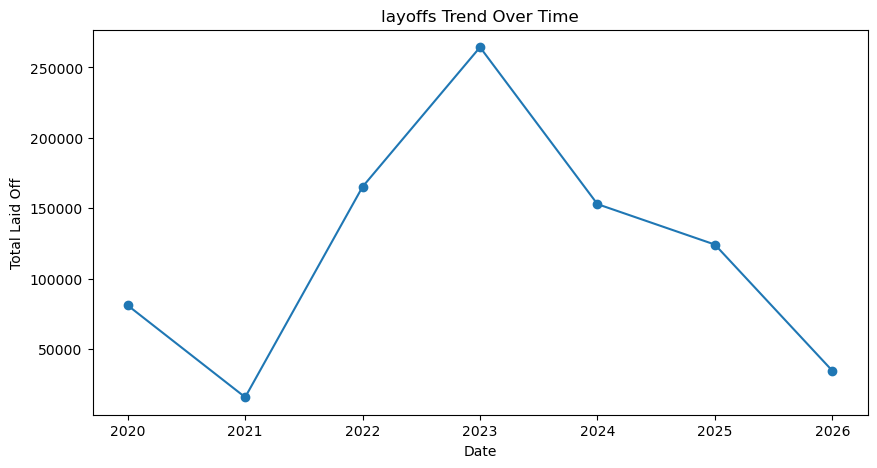

In [30]:
plt.figure(figsize=(10,5))
df.groupby('year')['total_laid_off'].sum().plot(kind='line', marker='o')
plt.title("layoffs Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Laid Off")
plt.savefig("../3_images/layoffs_trend.png", bbox_inches="tight")
plt.show()

1.Retail and Hardware industries experienced the highest layoffs.
2.The united States accounted for the majority of layoffs globally.
3.Layoffs peaked in 2023 following the post-pandemic hiring surge.

In [31]:
df["month"]=df['date'].dt.to_period("M")

In [32]:
monthly_layoffs=df.groupby("month")["total_laid_off"].sum()
monthly_layoffs

month
2020-03     9628.0
2020-04    26710.0
2020-05    25804.0
2020-06     7627.0
2020-07     7112.0
            ...   
2025-10    19070.0
2025-11     8932.0
2025-12     1552.0
2026-01    24818.0
2026-02     9832.0
Freq: M, Name: total_laid_off, Length: 71, dtype: float64

## Monthly Layoff Trend
This chart visualizes layoffs by month, helping to observe short-term fluctuations and identify months with major layoff events.

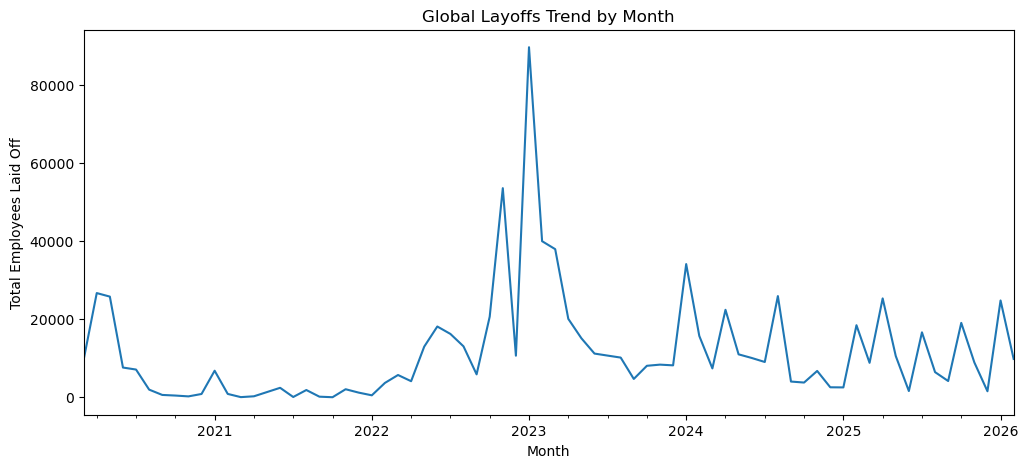

In [33]:

monthly_layoffs.plot(figsize=(12,5))
plt.title("Global Layoffs Trend by Month")
plt.xlabel("Month")
plt.ylabel("Total Employees Laid Off")
plt.savefig("../3_images/layoffs_by_month.png", bbox_inches="tight")


plt.show()

## Largest Layoffs Events by Company
This chart highlights companies with the largest layoff events, allowing us to identify major workforce reductions across organizations.

In [34]:
largest_layoffs=df.sort_values("total_laid_off", ascending=False)
largest_layoffs[["company", "industry", "country","total_laid_off","date"]].head(10)

,company,industry,country,total_laid_off,date
219,Intel,Hardware,United States,22000.0,2025-04-23
21,Amazon,Retail,United States,16000.0,2026-01-28
483,Intel,Hardware,United States,15000.0,2024-08-01
78,Amazon,Retail,United States,14000.0,2025-10-27
622,Tesla,Transportation,United States,14000.0,2024-04-15
1830,Google,Consumer,United States,12000.0,2023-01-20
2229,Meta,Consumer,United States,11000.0,2022-11-09
1855,Microsoft,Other,United States,10000.0,2023-01-18
1550,Meta,Consumer,United States,10000.0,2023-03-14
2171,Amazon,Retail,United States,10000.0,2022-11-16


## 5.Visualizations

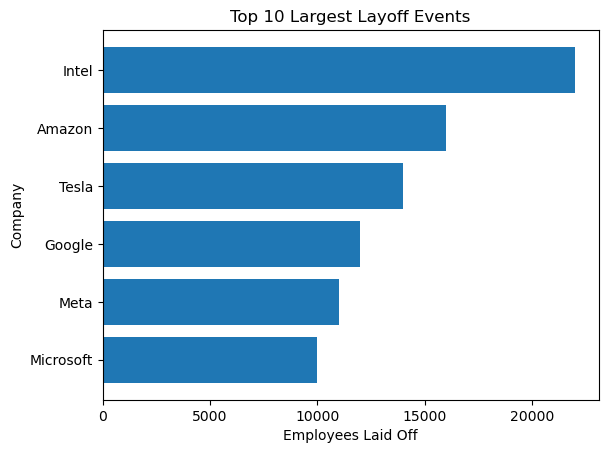

In [35]:
top10=largest_layoffs.head(10)
plt.Figure(figsize=(10,6))
plt.barh(top10["company"], top10["total_laid_off"])
plt.title("Top 10 Largest Layoff Events")
plt.xlabel("Employees Laid Off")
plt.ylabel("Company")
plt.gca().invert_yaxis()
plt.savefig("../3_images/layoffs_by_company.png", bbox_inches="tight")
plt.show()

In [36]:
industry_layoffs=df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False)
industry_layoffs.head(10)

industry
Retail            105261.0
Hardware           94957.0
Other              87635.0
Consumer           85060.0
Transportation     65706.0
Finance            58034.0
Food               50811.0
Healthcare         38904.0
Travel             23720.0
Sales              21269.0
Name: total_laid_off, dtype: float64

## Industry Layoffs Chart
This Visualization shows which industries experienced the highest number of layoffs during the observed period.

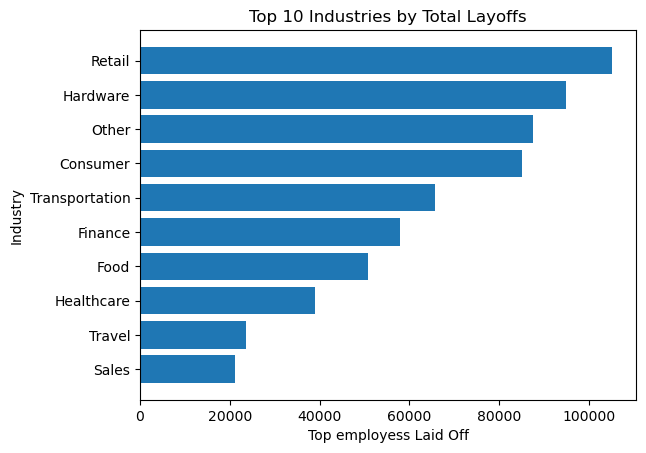

In [37]:
top_industries=industry_layoffs.head(10)
plt.Figure(figsize=(10,6))
plt.barh(top_industries.index, top_industries.values)
plt.title("Top 10 Industries by Total Layoffs")
plt.xlabel("Top employess Laid Off")
plt.ylabel("Industry")
plt.gca().invert_yaxis()
plt.savefig("../3_images/layoffs_by_industry.png", bbox_inches="tight")
plt.show()

In [38]:
country_layoffs=df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False)
country_layoffs.head(10)

country
United States     583624.0
India              65084.0
Germany            31488.0
United Kingdom     22027.0
Netherlands        21575.0
Sweden             20144.0
Canada             15787.0
Israel             12997.0
Brazil             11539.0
China               8190.0
Name: total_laid_off, dtype: float64

## Country Layoffs Chart
This chart compares layoffs across different countries, helping identify which regions were most affected.

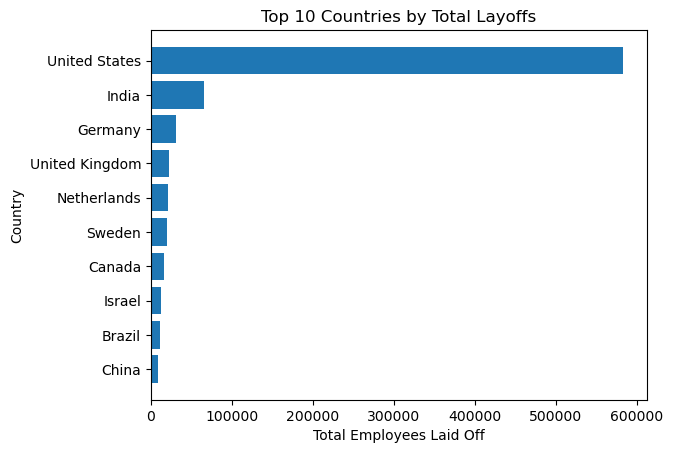

In [39]:
top_countries=country_layoffs.head(10)

plt.Figure(figsize=(10,6))
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Total Layoffs")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.savefig("../3_images/layoffs_by_country.png", bbox_inches="tight")
plt.show()

## 7.Correlation Analysis

In [40]:
df[["funds_raised", "total_laid_off"]].corr()

,funds_raised,total_laid_off
funds_raised,1.000000,0.109459
total_laid_off,0.109459,1.000000


## Funding vs Layoffs Scatter Plot
This Scatter plot explores whether companies that raised more funding experienced larger layoffs.

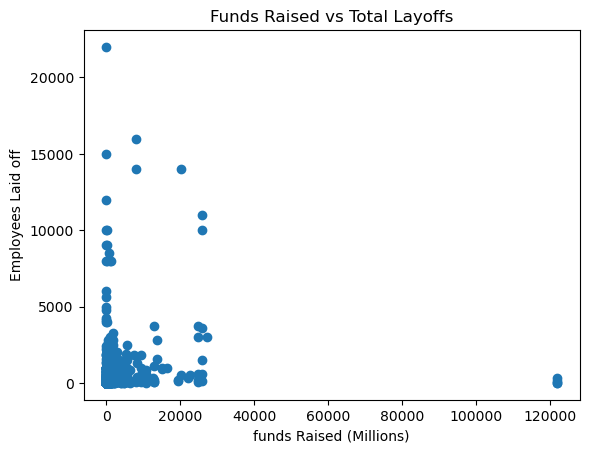

In [41]:

plt.Figure(figsize=(8,6))
plt.scatter(df["funds_raised"], df["total_laid_off"])
plt.title("Funds Raised vs Total Layoffs")
plt.xlabel("funds Raised (Millions)")
plt.ylabel("Employees Laid off")
plt.savefig("../3_images/funds_vs_total_layoff.png", bbox_inches="tight")
plt.show()

Insight:
The Correlation between funds raised and total layoffs is 0.109, indicating a very weak relationship.
This suggests that layoffs are not strongly dependent on the amount of funding raised, and may instead be influenced by other factors such as market conditions, company strategy, or industry trends.


## Final Conclusion
1. layoffs increased significantly around 2022-2023.
2.The Retail and Hardware industries experiences the largest layoffs.
3.The united States had the highest number of layoffs globally.
4.Major companies Like Intel, Amazon, and Meta had some of the largest layoffs events.
5.The correlation between funding and layoffs was very weak , suggesting other factors influences layoffs.